In [53]:
import pandas as pd
df = pd.read_csv('dataset.csv')

In [54]:
df.head()

,NUMBER_PR,SYSTEM,URL,NFR_TYPE,PHRASE,KEYWORDS,LOCATION,OBS
0,4119,Spring Boot,https://github.com/spring-projects/spring-boot/pull/4119,NaN,-,-,-,Added support for detecting the DB2 Universal JDBC driver
1,3160,Spring Boot,https://github.com/spring-projects/spring-boot/pull/3160,Maintainability,"""Fix default value""","""fix default""",Title,NaN
2,4618,Spring Boot,https://github.com/spring-projects/spring-boot/pull/4618,Maintainability,""" be a little brittle and had to maintain""","""maintain""",Discussion,-
3,22164,Spring Boot,https://github.com/spring-projects/spring-boot/pull/22164,Maintainability,"""favour of it being maintained by the Atomikos team""","""maintained""",Discussion,-
4,15594,Spring Boot,https://github.com/spring-projects/spring-boot/pull/15594,NaN,-,-,-,-


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1397 entries, 0 to 1396
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   NUMBER_PR  1397 non-null   int64 
 1   SYSTEM     1397 non-null   object
 2   URL        1347 non-null   object
 3   NFR_TYPE   477 non-null    object
 4   PHRASE     709 non-null    object
 5   KEYWORDS   694 non-null    object
 6   LOCATION   704 non-null    object
 7   OBS        421 non-null    object
dtypes: int64(1), object(7)
memory usage: 87.4+ KB


In [56]:
df = df.replace('-', pd.NA)

In [ ]:
df = df.dropna(subset=['URL', 'NFR_TYPE'])  # Teoricamente inválidos
df.shape

(449, 8)

## Distributions

<Axes: ylabel='NFR_TYPE'>

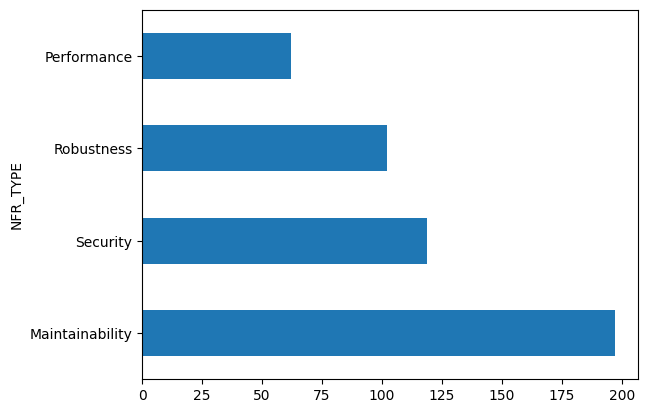

In [58]:
df_e = df.copy()

df_e['NFR_TYPE'] = df_e['NFR_TYPE'].str.split(',')
df_e = df_e.explode('NFR_TYPE')

df_e['NFR_TYPE'] = df_e['NFR_TYPE'].str.strip()

df_e['NFR_TYPE'].value_counts().plot.barh()

In [ ]:
df_sec = df[df['NFR_TYPE'].str.contains('Security')].copy()
df_sec.shape  # PRs de segurança

(119, 8)

<Axes: ylabel='SYSTEM'>

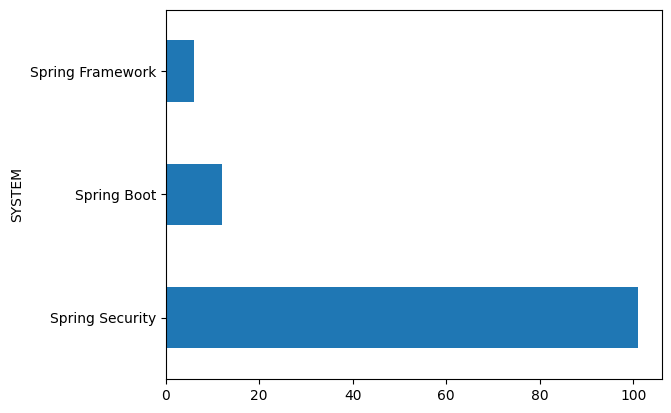

In [60]:
df_sec['SYSTEM'].value_counts().plot.barh()

<Axes: ylabel='count'>

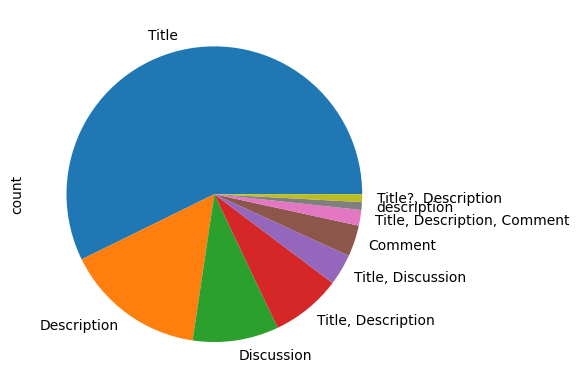

In [61]:
df_sec['LOCATION'].value_counts().plot.pie()

In [62]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def w_cloud(column):
    # Junta tudo em um único texto
    texto = ' '.join(df_sec[column].dropna())

    # Cria a nuvem
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(texto)

    # Plota
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

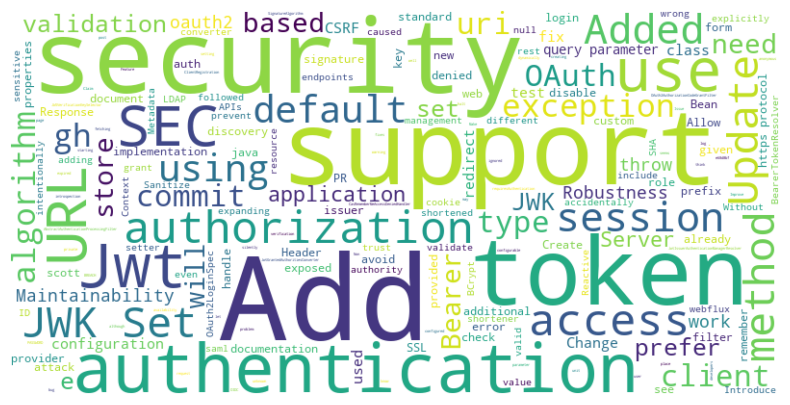

In [63]:
w_cloud('PHRASE')

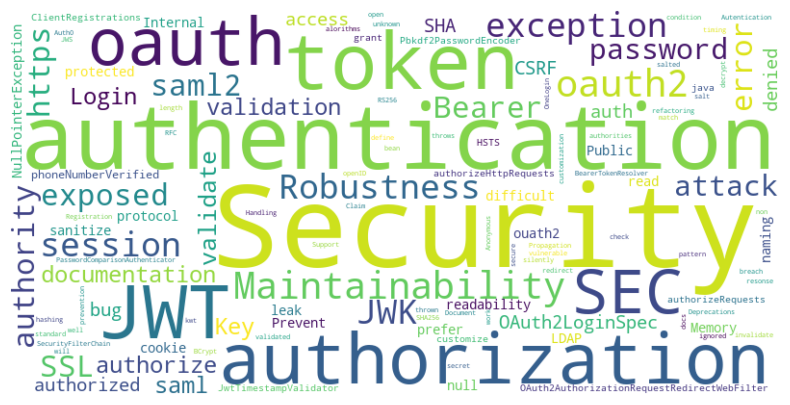

In [64]:
w_cloud('KEYWORDS')

## Links

In [68]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

df_sec['URL'][df_sec['OBS'].isna()]  # Sem obsevação

7            https://github.com/spring-projects/spring-boot/pull/10000
37            https://github.com/spring-projects/spring-boot/pull/5852
136          https://github.com/spring-projects/spring-boot/pull/17952
152           https://github.com/spring-projects/spring-boot/pull/2816
184          https://github.com/spring-projects/spring-boot/pull/17939
205          https://github.com/spring-projects/spring-boot/pull/14985
246          https://github.com/spring-projects/spring-boot/pull/15163
256           https://github.com/spring-projects/spring-boot/pull/1732
296           https://github.com/spring-projects/spring-boot/pull/1545
299          https://github.com/spring-projects/spring-boot/pull/20747
313           https://github.com/spring-projects/spring-boot/pull/2922
326           https://github.com/spring-projects/spring-boot/pull/6876
483      https://github.com/spring-projects/spring-framework/pull/1277
536      https://github.com/spring-projects/spring-framework/pull/1889
648   

In [66]:
df_sec.loc[df_sec['OBS'].notna(), ['NUMBER_PR', 'URL', 'OBS']]

,NUMBER_PR,URL,OBS
969,84,https://github.com/spring-projects/spring-security/pull/84,The NFR is infered by the tag SEC-2560 mentioned in the Title
970,7491,https://github.com/spring-projects/spring-security/pull/7491,SAML 2.0 is an XML-based protocol that uses security tokens
979,8400,https://github.com/spring-projects/spring-security/pull/8400,"LDAP is a software protocol for enabling anyone to locate data about organizations, individuals and other resources such as files and devices in a network"
1061,11317,https://github.com/spring-projects/spring-security/pull/11317,Identificação acaba sendo mais pelo contexto e pela label do que pelas keywords em si.
1073,6393,https://github.com/spring-projects/spring-security/pull/6393,"Já não é o primeiro caso em que a keyword está dentro de uma palavra maior. Normalmente acontece quando o título se refere ao nome de uma classe (e.g. JwtTimestampValidator.java, Pbkdf2PasswordEncoder, etc.)"
1100,4897,https://github.com/spring-projects/spring-security/pull/4897,"Identifiquei manutenibilidade pelo contexto, mas não encontrei nenhuma keyword específica que pudesse apontar o NFR."
1132,14,https://github.com/spring-projects/spring-security/pull/14,Discussão interessante
1148,7356,https://github.com/spring-projects/spring-security/pull/7356,PR Rejeitada
1169,7221,https://github.com/spring-projects/spring-security/pull/7221,não foi implementado
1321,9779,https://github.com/spring-projects/spring-security/pull/9779,"É um daqueles casos complexos onde olhando só para as keywords poderia dar um falso positivo. Fiquei na dúvida originalmente se marcaria esse como de segurança, e olhando só para o corpo da issue e os comentários continuei na dúvida. Porém, dentro do corpo da PR tem uma issue linkada, que explica que essa mudança tem a ver com a conformidade com o padrão de requisição de autenticação do oauth2. Sendo isso, considerei de segurança."


In [67]:
df_sec.loc[df_sec['OBS'].notna(), ['URL', 'OBS']].shape

(13, 2)